# RAG Evaluation Framework — TFE Phuket

**Métriques :** FA · UOCR · Latency · Refinement Gain · Answer Relevancy · Cross-Language Consistency · Intent Fidelity

**Modèles testés :** phi3:mini · llama3.1:8b · qwen2.5:14b · gpt-4o-mini

Exécuter les sections dans l'ordre. La section 1 (collecte) est la plus longue (~1-2h).

## 0. Setup & Configuration

In [ ]:
import sys, os, json, time, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from datetime import datetime

# Paths
ROOT = Path('../../').resolve()
sys.path.insert(0, str(ROOT / 'backend'))
os.chdir(ROOT)

from dotenv import load_dotenv
load_dotenv(ROOT / 'backend' / '.env')

# --- Thesis-consistent plot style (white background) ---
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'savefig.facecolor': 'white',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 10,
})
sns.set_style('whitegrid')

# Consistent model colors (same order every chart)
MODELS = [
    'phi3:mini',
    'llama3.1:8b-instruct-q4_K_M',
    'qwen2.5:14b',
    'gpt-4o-mini',
]
MODEL_LABELS = {
    'phi3:mini':                     'phi3',
    'llama3.1:8b-instruct-q4_K_M':  'llama3.1',
    'qwen2.5:14b':                   'qwen2.5',
    'gpt-4o-mini':                   'gpt-4o-mini',
}
MODEL_COLORS = {
    'phi3:mini':                    '#4C72B0',
    'llama3.1:8b-instruct-q4_K_M': '#DD8452',
    'qwen2.5:14b':                  '#55A868',
    'gpt-4o-mini':                  '#C44E52',
}

FIGSIZE = (12, 5)

# Load benchmark
with open(ROOT / 'notebooks' / 'eval' / 'benchmark.json') as f:
    BENCHMARK = json.load(f)

RESULTS_DIR = ROOT / 'notebooks' / 'eval' / 'results'
RESULTS_DIR.mkdir(exist_ok=True)

print(f'Benchmark: {len(BENCHMARK)} questions')
print(f'Models: {MODELS}')
print(f'Results dir: {RESULTS_DIR}')

Benchmark: 60 questions
Models: ['phi3:mini', 'llama3.1:8b-instruct-q4_K_M', 'qwen2.5:14b', 'gpt-4o-mini']
Results dir: /Users/mathieuzilli/Desktop/Thai/TFE_Phuket/notebooks/eval/results


## 1. Run RAG — Collecte des réponses

Boucle principale : question × modèle × refine ON/OFF. Sauvegarde dans `results_df`.  
**Durée estimée :** ~1-2h pour 4 modèles × 60 questions × 2 configs.  
Les résultats sont sauvegardés au fur et à mesure — interruptible.

In [2]:
from rag.retriever import retrieve_context
from rag.prompt_builder import build_prompt, call_llm, refine_answer, parse_chart_from_response

CACHE_PATH = RESULTS_DIR / 'raw_responses.csv'

rows = []
total = len(BENCHMARK) * len(MODELS) * 2  # ×2 for refine ON/OFF
done = 0

for q in BENCHMARK:
    for model in MODELS:
        for refine_on in [False, True]:
            done += 1
            print(f'[{done}/{total}] {q["id"]} | {model} | refine={refine_on}', end=' ... ')
            t0 = time.perf_counter()
            try:
                chunks = retrieve_context(q['question_en'], q['corridor_id'])
                t_retrieve = time.perf_counter() - t0

                prompt = build_prompt(q['question_en'], chunks, include_chart=False)
                t1 = time.perf_counter()
                raw = call_llm(prompt, model=model)
                t_llm = time.perf_counter() - t1

                if refine_on and not raw.startswith('['):
                    t2 = time.perf_counter()
                    refined = refine_answer(raw, model=model)
                    t_refine = time.perf_counter() - t2
                    final_answer = refined
                else:
                    refined = None
                    t_refine = 0.0
                    final_answer = raw

                rows.append({
                    'id': q['id'], 'intent': q['intent'], 'corridor_id': q['corridor_id'],
                    'model': model, 'refine': refine_on,
                    'question': q['question_en'],
                    'answer': final_answer, 'raw_answer': raw,
                    'expected_value': q.get('expected_value'),
                    'expected_unit': q.get('expected_unit'),
                    'out_of_scope': q['out_of_scope'],
                    'n_chunks': len(chunks),
                    't_retrieve_s': round(t_retrieve, 3),
                    't_llm_s': round(t_llm, 3),
                    't_refine_s': round(t_refine, 3),
                    't_total_s': round(t_retrieve + t_llm + t_refine, 3),
                    'error': None,
                })
                print(f'{t_llm:.1f}s LLM + {t_refine:.1f}s refine')
            except Exception as e:
                rows.append({'id': q['id'], 'model': model, 'refine': refine_on,
                             'question': q['question_en'], 'answer': None, 'error': str(e)})
                print(f'ERROR: {e}')

results_df = pd.DataFrame(rows)
results_df.to_csv(CACHE_PATH, index=False)
print(f'\nSaved {len(results_df)} rows to {CACHE_PATH}')

[1/480] FA_001 | phi3:mini | refine=False ... 

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

2.6s LLM + 0.0s refine
[2/480] FA_001 | phi3:mini | refine=True ... 0.4s LLM + 0.7s refine
[3/480] FA_001 | llama3.1:8b-instruct-q4_K_M | refine=False ... 3.5s LLM + 0.0s refine
[4/480] FA_001 | llama3.1:8b-instruct-q4_K_M | refine=True ... 0.3s LLM + 0.8s refine
[5/480] FA_001 | qwen2.5:14b | refine=False ... 7.6s LLM + 0.0s refine
[6/480] FA_001 | qwen2.5:14b | refine=True ... 0.9s LLM + 1.3s refine
[7/480] FA_001 | gpt-4o-mini | refine=False ... 3.2s LLM + 0.0s refine
[8/480] FA_001 | gpt-4o-mini | refine=True ... 2.2s LLM + 1.6s refine
[9/480] FA_002 | phi3:mini | refine=False ... 1.9s LLM + 0.0s refine
[10/480] FA_002 | phi3:mini | refine=True ... 0.6s LLM + 0.8s refine
[11/480] FA_002 | llama3.1:8b-instruct-q4_K_M | refine=False ... 3.2s LLM + 0.0s refine
[12/480] FA_002 | llama3.1:8b-instruct-q4_K_M | refine=True ... 0.4s LLM + 0.9s refine
[13/480] FA_002 | qwen2.5:14b | refine=False ... 5.5s LLM + 0.0s refine
[14/480] FA_002 | qwen2.5:14b | refine=True ... 

KeyboardInterrupt: 

In [ ]:
# Load from cache if already collected
results_df = pd.read_csv(RESULTS_DIR / 'raw_responses.csv')
print(f'Loaded {len(results_df)} rows')
results_df.head(3)

Loaded 480 rows


,id,intent,corridor_id,model,refine,question,answer,raw_answer,expected_value,expected_unit,out_of_scope,n_chunks,t_retrieve_s,t_llm_s,t_refine_s,t_total_s,error
0,FA_001,nowcast,0,phi3:mini,False,What is the weekday AM peak speed on Airport R...,According to traffic_monthly data from Jan 202...,According to traffic_monthly data from Jan 202...,42.72,km/h,False,6,10.750,2.790,0.000,13.540,NaN
1,FA_001,nowcast,0,phi3:mini,True,What is the weekday AM peak speed on Airport R...,"Based on the traffic data for January 2024, he...",According to traffic_monthly data from Jan 202...,42.72,km/h,False,6,0.019,0.387,0.767,1.174,NaN
2,FA_001,nowcast,0,llama3.1:8b-instruct-q4_K_M,False,What is the weekday AM peak speed on Airport R...,The weekday AM peak speed on Airport Road in J...,The weekday AM peak speed on Airport Road in J...,42.72,km/h,False,6,0.044,3.696,0.000,3.740,NaN


## 2. Factual Accuracy (FA) + UOCR

**FA:** Pour les questions avec `expected_value`, extrait le nombre de la réponse et vérifie à ±5%.  
**UOCR:** Pour les questions `out_of_scope`, détecte si le modèle refuse honnêtement.

In [ ]:
REFUSAL_PHRASES = [
    "don't have", "do not have", "no information", "not available",
    "cannot find", "no data", "outside", "not in", "unable to", "no relevant",
    "i don't know", "beyond the scope", "not covered"
]

def check_factual(row) -> bool | None:
    """Search for expected_value anywhere in the response (all numbers, not just first)."""
    if pd.isna(row.get('expected_value')):
        return None
    if not isinstance(row['answer'], str):
        return False
    expected = float(row['expected_value'])
    tolerance = abs(expected) * 0.05 + 0.01  # 5% relative + small absolute guard
    # Extract ALL numbers from the full response
    nums = re.findall(r'\b(\d[\d,]*\.?\d*)\b', row['answer'].replace(',', ''))
    for n_str in nums:
        try:
            if abs(float(n_str) - expected) <= tolerance:
                return True
        except ValueError:
            continue
    return False

def check_refusal(answer: str) -> bool:
    if not isinstance(answer, str):
        return False
    low = answer.lower()
    return any(p in low for p in REFUSAL_PHRASES)

# Apply metrics
df = results_df.copy()
df['fa_correct'] = df.apply(check_factual, axis=1)
df['is_refusal'] = df['answer'].apply(check_refusal)

# FA - only on factual questions with expected values (refine=False for base comparison)
fa_df = df[df['fa_correct'].notna() & ~df['refine']]
fa_by_model = fa_df.groupby('model')['fa_correct'].mean().reindex(MODELS).fillna(0)

# UOCR - only on out_of_scope questions
oos_df = df[df['out_of_scope'] == True]
uocr_by_model = oos_df.groupby('model')['is_refusal'].mean().reindex(MODELS).fillna(0)

print('=== Factual Accuracy (FA) - fixed: searches expected_value anywhere in response ===')
print(fa_by_model.to_string())
print('\n=== UOCR ===')
print(uocr_by_model.to_string())

=== Factual Accuracy (FA) - fixed: searches expected_value anywhere in response ===
model
phi3:mini                      0.833333
llama3.1:8b-instruct-q4_K_M    0.916667
qwen2.5:14b                    0.916667
gpt-4o-mini                    0.916667

=== UOCR ===
model
phi3:mini                      0.375
llama3.1:8b-instruct-q4_K_M    0.750
qwen2.5:14b                    0.500
gpt-4o-mini                    0.625


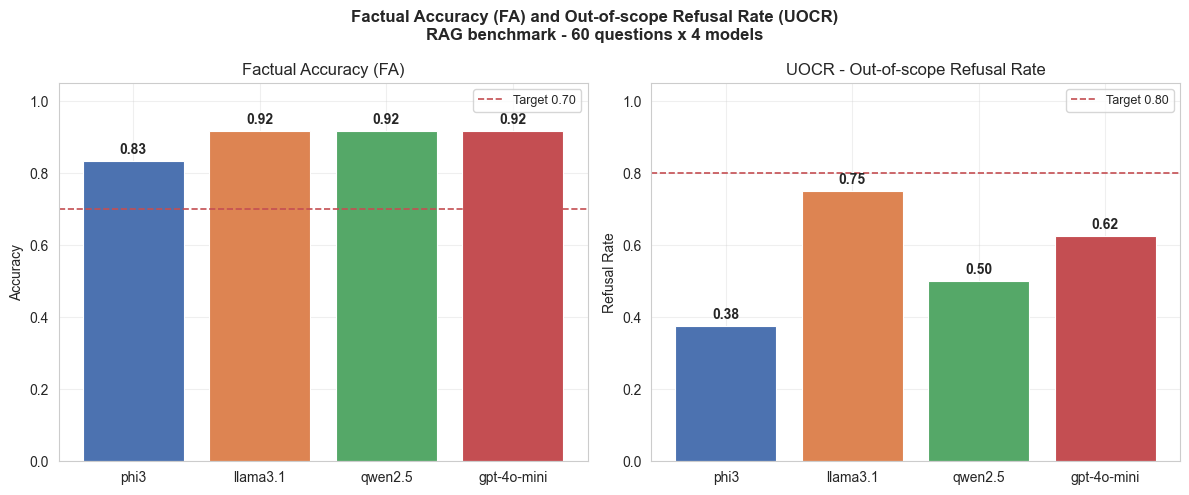

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)
fig.suptitle('Factual Accuracy (FA) and Out-of-scope Refusal Rate (UOCR)\nRAG benchmark - 60 questions x 4 models',
             fontsize=12, fontweight='bold')

labels = [MODEL_LABELS[m] for m in MODELS]
colors = [MODEL_COLORS[m] for m in MODELS]

# FA chart
bars = axes[0].bar(labels, fa_by_model.values, color=colors, edgecolor='white', linewidth=0.8)
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Factual Accuracy (FA)')
axes[0].axhline(0.7, color='#C44E52', linestyle='--', linewidth=1.2, label='Target 0.70')
axes[0].legend(fontsize=9)
for bar, v in zip(bars, fa_by_model.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.02, f'{v:.2f}',
                 ha='center', fontsize=10, fontweight='bold')

# UOCR chart
bars2 = axes[1].bar(labels, uocr_by_model.values, color=colors, edgecolor='white', linewidth=0.8)
axes[1].set_ylim(0, 1.05)
axes[1].set_ylabel('Refusal Rate')
axes[1].set_title('UOCR - Out-of-scope Refusal Rate')
axes[1].axhline(0.8, color='#C44E52', linestyle='--', linewidth=1.2, label='Target 0.80')
axes[1].legend(fontsize=9)
for bar, v in zip(bars2, uocr_by_model.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.02, f'{v:.2f}',
                 ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'fa_uocr.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## 3. Latency

Temps de réponse par modèle × configuration (avec/sans refine).

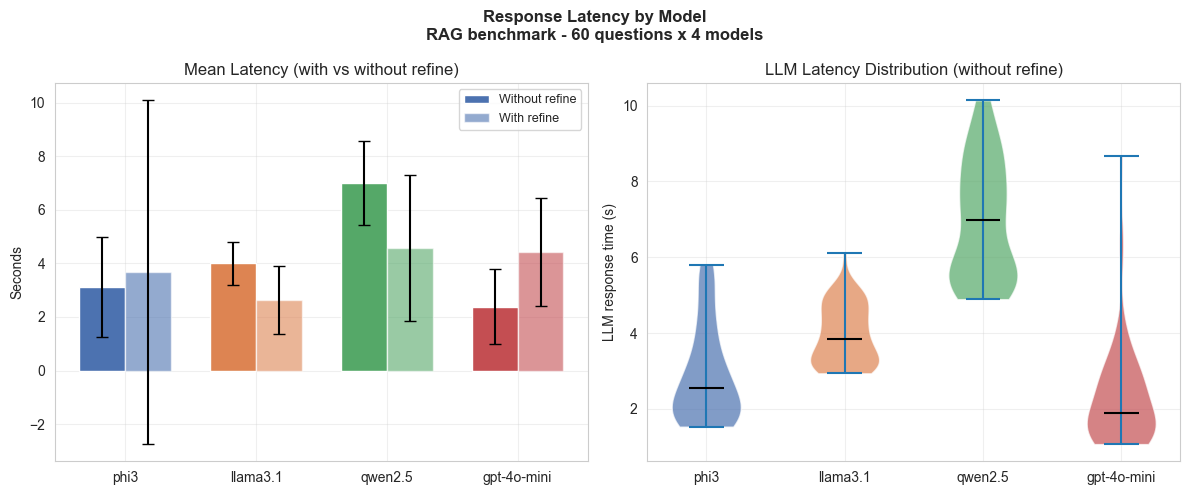

                      model  refine     mean      std
                gpt-4o-mini   False 2.382183 1.393774
                gpt-4o-mini    True 4.419867 2.013387
llama3.1:8b-instruct-q4_K_M   False 3.998283 0.796367
llama3.1:8b-instruct-q4_K_M    True 2.633117 1.257480
                  phi3:mini   False 3.119100 1.865336
                  phi3:mini    True 3.672467 6.416900
                qwen2.5:14b   False 6.986917 1.567818
                qwen2.5:14b    True 4.566133 2.725859


In [ ]:
lat_df = results_df[results_df['error'].isna()].copy()
lat_summary = lat_df.groupby(['model', 'refine'])['t_total_s'].agg(['mean', 'std']).reset_index()

labels = [MODEL_LABELS[m] for m in MODELS]
colors = [MODEL_COLORS[m] for m in MODELS]
x = np.arange(len(MODELS))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)
fig.suptitle('Response Latency by Model\nRAG benchmark - 60 questions x 4 models',
             fontsize=12, fontweight='bold')

# Grouped bar: with vs without refine
for i, (refine_val, label, alpha) in enumerate([(False, 'Without refine', 1.0), (True, 'With refine', 0.6)]):
    sub = lat_summary[lat_summary['refine'] == refine_val].set_index('model').reindex(MODELS)
    bar_colors = [MODEL_COLORS[m] for m in MODELS]
    axes[0].bar(x + i*width - width/2, sub['mean'].fillna(0).values, width,
                label=label, color=bar_colors, alpha=alpha,
                yerr=sub['std'].fillna(0).values, capsize=4, edgecolor='white')

axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_ylabel('Seconds')
axes[0].set_title('Mean Latency (with vs without refine)')
axes[0].legend(fontsize=9)

# Violin per model (no refine only)
no_refine = lat_df[~lat_df['refine']]
data_by_model = [no_refine[no_refine['model'] == m]['t_llm_s'].dropna().values for m in MODELS]
vp = axes[1].violinplot(data_by_model, showmedians=True)
for i, (body, m) in enumerate(zip(vp['bodies'], MODELS)):
    body.set_facecolor(MODEL_COLORS[m])
    body.set_alpha(0.7)
vp['cmedians'].set_color('black')
axes[1].set_xticks(range(1, len(MODELS)+1))
axes[1].set_xticklabels(labels)
axes[1].set_ylabel('LLM response time (s)')
axes[1].set_title('LLM Latency Distribution (without refine)')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'latency.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print(lat_summary.to_string(index=False))

## 4. Refinement Gain (RG)

Delta de qualité entre réponse brute et réponse après refine agent, mesuré via BERTScore.

In [ ]:
try:
    from bert_score import score as bert_score
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'bert-score', '-q'])
    from bert_score import score as bert_score

# Pair raw vs refined for same question/model
raw_df = results_df[~results_df['refine'] & results_df['answer'].notna()][['id','model','answer']].rename(columns={'answer':'raw'})
ref_df = results_df[results_df['refine'] & results_df['answer'].notna()][['id','model','answer']].rename(columns={'answer':'refined'})
paired = raw_df.merge(ref_df, on=['id','model'])

print(f'Computing BERTScore for {len(paired)} pairs...')
_, _, F_raw = bert_score(paired['raw'].tolist(), paired['refined'].tolist(),
                          lang='en', verbose=False)

paired['bertscore_raw_vs_refined'] = F_raw.numpy()
# Gain = how much refined differs from raw (1 = identical, lower = more changed)
# We interpret high change as more effort by refine agent
paired['refinement_delta'] = 1 - paired['bertscore_raw_vs_refined']

rg_by_model = paired.groupby('model')['refinement_delta'].mean()
print('\nRefinement delta by model (higher = more rewriting done):')
print(rg_by_model.to_string())

Computing BERTScore for 240 pairs...


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Refinement delta by model (higher = more rewriting done):
model
gpt-4o-mini                    0.084917
llama3.1:8b-instruct-q4_K_M    0.097636
phi3:mini                      0.130063
qwen2.5:14b                    0.082796


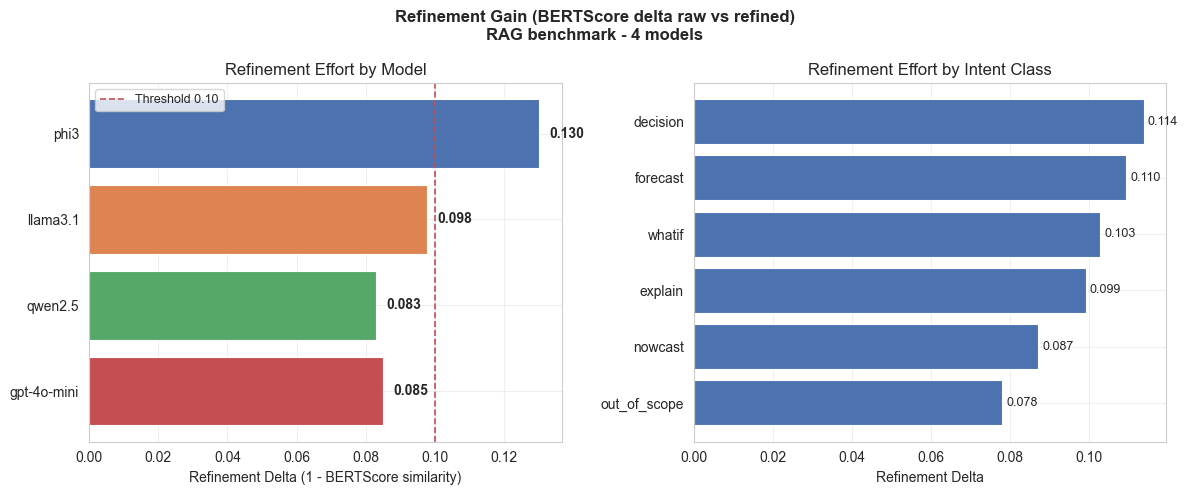

In [ ]:
paired_with_intent = paired.merge(results_df[['id','intent']].drop_duplicates(), on='id')

labels = [MODEL_LABELS[m] for m in MODELS]
colors = [MODEL_COLORS[m] for m in MODELS]

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)
fig.suptitle('Refinement Gain (BERTScore delta raw vs refined)\nRAG benchmark - 4 models',
             fontsize=12, fontweight='bold')

rg_ordered = rg_by_model.reindex(MODELS)
bars = axes[0].barh(labels[::-1], rg_ordered.values[::-1],
                    color=colors[::-1], edgecolor='white', linewidth=0.8)
axes[0].set_xlabel('Refinement Delta (1 - BERTScore similarity)')
axes[0].set_title('Refinement Effort by Model')
axes[0].axvline(0.1, color='#C44E52', linestyle='--', linewidth=1.2, label='Threshold 0.10')
axes[0].legend(fontsize=9)
for bar, v in zip(bars, rg_ordered.values[::-1]):
    axes[0].text(v + 0.003, bar.get_y() + bar.get_height()/2, f'{v:.3f}',
                 va='center', fontsize=10, fontweight='bold')

rg_by_intent = paired_with_intent.groupby('intent')['refinement_delta'].mean().sort_values()
intent_colors = ['#4C72B0'] * len(rg_by_intent)
axes[1].barh(rg_by_intent.index, rg_by_intent.values,
             color='#4C72B0', edgecolor='white', linewidth=0.8)
axes[1].set_xlabel('Refinement Delta')
axes[1].set_title('Refinement Effort by Intent Class')
for i, (intent, v) in enumerate(rg_by_intent.items()):
    axes[1].text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'refinement_gain.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## 5. Answer Relevancy (AR)

Cosine similarity entre l'embedding de la question et l'embedding de la réponse.  
Utilise `all-MiniLM-L6-v2` déjà installé via sentence-transformers.

In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

model_embed = SentenceTransformer('all-MiniLM-L6-v2')

df_ar = results_df[results_df['answer'].notna() & ~results_df['refine']].copy()
questions_emb = model_embed.encode(df_ar['question'].tolist(), show_progress_bar=True)
answers_emb   = model_embed.encode(df_ar['answer'].tolist(),   show_progress_bar=True)

df_ar['ar_score'] = [cosine_similarity([q], [a])[0][0]
                     for q, a in zip(questions_emb, answers_emb)]

ar_by_model  = df_ar.groupby('model')['ar_score'].mean().sort_values(ascending=False)
ar_by_intent = df_ar.groupby('intent')['ar_score'].mean().sort_values(ascending=False)

print('=== Answer Relevancy by model ===')
print(ar_by_model.to_string())
print('\n=== Answer Relevancy by intent ===')
print(ar_by_intent.to_string())

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/8 [00:00<?, ?it/s]

Batches:   0%|          | 0/8 [00:00<?, ?it/s]

=== Answer Relevancy by model ===
model
gpt-4o-mini                    0.835611
qwen2.5:14b                    0.781665
llama3.1:8b-instruct-q4_K_M    0.776716
phi3:mini                      0.715707

=== Answer Relevancy by intent ===
intent
nowcast         0.824713
out_of_scope    0.791835
explain         0.776575
whatif          0.759718
forecast        0.752589
decision        0.752542


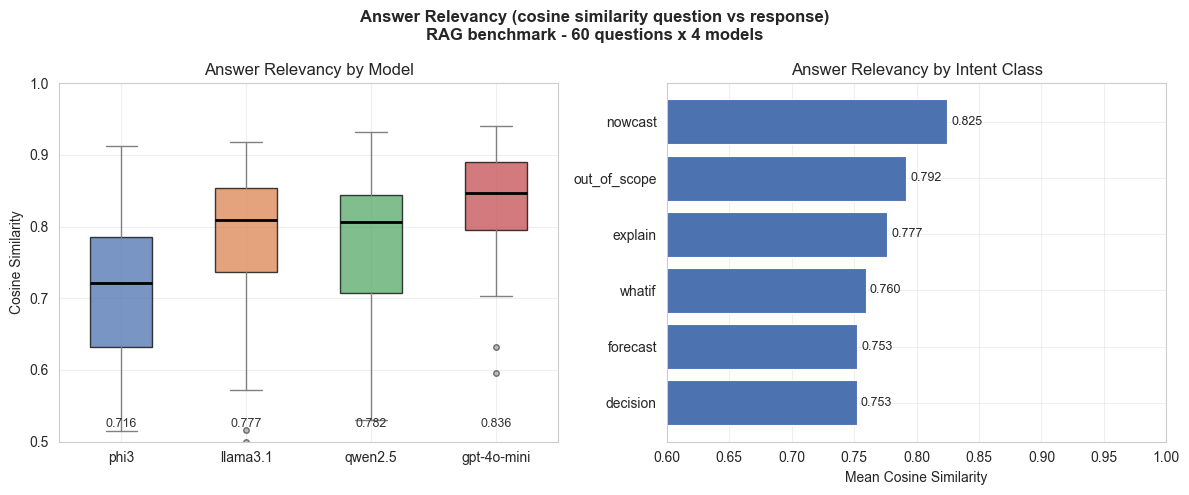

In [ ]:
labels = [MODEL_LABELS[m] for m in MODELS]
colors = [MODEL_COLORS[m] for m in MODELS]

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)
fig.suptitle('Answer Relevancy (cosine similarity question vs response)\nRAG benchmark - 60 questions x 4 models',
             fontsize=12, fontweight='bold')

# Box plot by model
models_order = MODELS
data_boxes = [df_ar[df_ar['model'] == m]['ar_score'].values for m in models_order]
bp = axes[0].boxplot(data_boxes, patch_artist=True, widths=0.5,
                     medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
for whisker in bp['whiskers']:
    whisker.set_color('gray')
for cap in bp['caps']:
    cap.set_color('gray')
for flier in bp['fliers']:
    flier.set(marker='o', markerfacecolor='gray', markersize=4, alpha=0.5)
axes[0].set_xticklabels(labels)
axes[0].set_ylabel('Cosine Similarity')
axes[0].set_title('Answer Relevancy by Model')
axes[0].set_ylim(0.5, 1.0)
for i, (m, v) in enumerate(zip(MODELS, ar_by_model.reindex(MODELS).values)):
    axes[0].text(i+1, 0.52, f'{v:.3f}', ha='center', fontsize=9, color='#333333')

# By intent
ar_by_intent = df_ar.groupby('intent')['ar_score'].mean().sort_values()
axes[1].barh(ar_by_intent.index, ar_by_intent.values,
             color='#4C72B0', edgecolor='white', linewidth=0.8)
axes[1].set_xlabel('Mean Cosine Similarity')
axes[1].set_title('Answer Relevancy by Intent Class')
axes[1].set_xlim(0.6, 1.0)
for i, (intent, v) in enumerate(ar_by_intent.items()):
    axes[1].text(v + 0.003, i, f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'answer_relevancy.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## 6. Cross-Language Consistency (CLC)

Même question posée en EN / FR / TH. Similarity sémantique entre les réponses via embeddings multilingues.

In [ ]:
multilingual_model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

# Run RAG for FR and TH versions of the first 15 questions (subset for speed)
CLC_SUBSET = BENCHMARK[:15]  # adjust as needed
clc_rows = []

for q in CLC_SUBSET:
    for model in MODELS:
        for lang, question in [('en', q['question_en']), ('fr', q['question_fr']), ('th', q['question_th'])]:
            print(f"{q['id']} | {model} | {lang}", end=' ... ')
            t0 = time.perf_counter()
            try:
                chunks = retrieve_context(question, q['corridor_id'])
                prompt = build_prompt(question, chunks, include_chart=False)
                answer = call_llm(prompt, model=model)
                clc_rows.append({'id': q['id'], 'model': model, 'lang': lang,
                                  'question': question, 'answer': answer,
                                  'latency_s': round(time.perf_counter()-t0, 2)})
                print('OK')
            except Exception as e:
                print(f'ERROR: {e}')
                clc_rows.append({'id': q['id'], 'model': model, 'lang': lang,
                                  'question': question, 'answer': None, 'latency_s': None})

clc_df = pd.DataFrame(clc_rows)
clc_df.to_csv(RESULTS_DIR / 'clc_responses.csv', index=False)
print(f'CLC responses: {len(clc_df)} rows')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

FA_001 | phi3:mini | en ... OK
FA_001 | phi3:mini | fr ... OK
FA_001 | phi3:mini | th ... OK
FA_001 | llama3.1:8b-instruct-q4_K_M | en ... OK
FA_001 | llama3.1:8b-instruct-q4_K_M | fr ... OK
FA_001 | llama3.1:8b-instruct-q4_K_M | th ... OK
FA_001 | qwen2.5:14b | en ... OK
FA_001 | qwen2.5:14b | fr ... OK
FA_001 | qwen2.5:14b | th ... OK
FA_001 | gpt-4o-mini | en ... OK
FA_001 | gpt-4o-mini | fr ... OK
FA_001 | gpt-4o-mini | th ... OK
FA_002 | phi3:mini | en ... OK
FA_002 | phi3:mini | fr ... OK
FA_002 | phi3:mini | th ... OK
FA_002 | llama3.1:8b-instruct-q4_K_M | en ... OK
FA_002 | llama3.1:8b-instruct-q4_K_M | fr ... OK
FA_002 | llama3.1:8b-instruct-q4_K_M | th ... OK
FA_002 | qwen2.5:14b | en ... OK
FA_002 | qwen2.5:14b | fr ... OK
FA_002 | qwen2.5:14b | th ... OK
FA_002 | gpt-4o-mini | en ... OK
FA_002 | gpt-4o-mini | fr ... OK
FA_002 | gpt-4o-mini | th ... OK
FA_003 | phi3:mini | en ... OK
FA_003 | phi3:mini | fr ... OK
FA_003 | phi3:mini | th ... OK
FA_003 | llama3.1:8b-instruct-q

In [ ]:
# Load CLC cache if already collected
clc_df = pd.read_csv(RESULTS_DIR / 'clc_responses.csv')

# Compute pairwise similarities per question × model
clc_results = []
for (qid, model), grp in clc_df.groupby(['id', 'model']):
    grp = grp.dropna(subset=['answer'])
    lang_map = {row['lang']: row['answer'] for _, row in grp.iterrows()}
    if 'en' not in lang_map: continue
    embs = {l: multilingual_model.encode([a])[0] for l, a in lang_map.items()}
    for lang2 in ['fr', 'th']:
        if lang2 in embs:
            sim = cosine_similarity([embs['en']], [embs[lang2]])[0][0]
            clc_results.append({'id': qid, 'model': model, 'pair': f'en↔{lang2}', 'similarity': sim})

clc_scores = pd.DataFrame(clc_results)
pivot = clc_scores.groupby(['model', 'pair'])['similarity'].mean().unstack()
print(pivot.to_string())

pair                            en↔fr     en↔th
model                                          
gpt-4o-mini                  0.798891  0.815521
llama3.1:8b-instruct-q4_K_M  0.732279  0.798159
phi3:mini                    0.703065  0.766752
qwen2.5:14b                  0.776331  0.808405


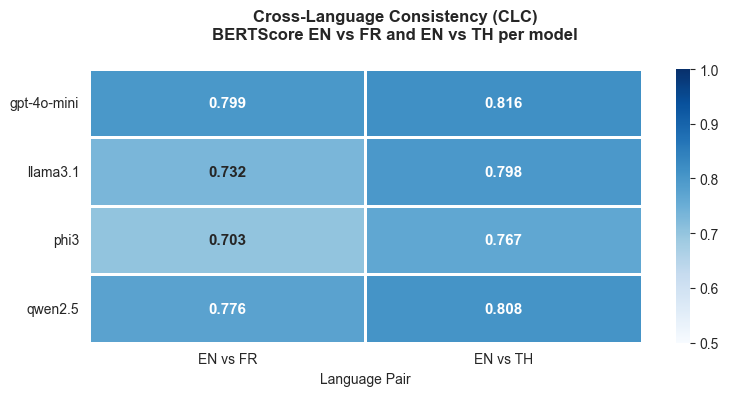

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
fig.suptitle('Cross-Language Consistency (CLC)\nBERTScore EN vs FR and EN vs TH per model',
             fontsize=12, fontweight='bold')

sns.heatmap(pivot, annot=True, fmt='.3f', cmap='Blues', vmin=0.5, vmax=1.0,
            ax=ax, linewidths=0.8, linecolor='white',
            annot_kws={'size': 11, 'weight': 'bold'})
ax.set_title('')
ax.set_xlabel('Language Pair')
ax.set_ylabel('')
ax.set_yticklabels([MODEL_LABELS.get(m, m) for m in pivot.index], rotation=0)
ax.set_xticklabels(['EN vs FR', 'EN vs TH'], rotation=0)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'crosslang_consistency.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## 7. Intent Fidelity (IF)

LLM-as-judge : GPT-4o-mini classifie le type de chaque réponse.  
On compare la classe prédite à l'intent attendu → confusion matrix.

In [ ]:
JUDGE_SYSTEM = """Classify the following answer into one of these categories:
- nowcast: describes current or recent traffic/weather conditions
- forecast: predicts future conditions or seasonal trends
- explain: explains causes or factors behind traffic patterns
- whatif: analyzes a hypothetical scenario
- decision: gives a recommendation or actionable advice
- out_of_scope: admits not having the information or refuses to answer

Reply with ONLY the category name, nothing else."""

def classify_answer(answer: str) -> str:
    if not isinstance(answer, str) or answer.startswith('['):
        return 'error'
    result = call_llm(f"Answer to classify:\n{answer[:500]}",
                       model='gpt-4o-mini', system=JUDGE_SYSTEM)
    result = result.strip().lower()
    valid = ['nowcast','forecast','explain','whatif','decision','out_of_scope']
    return result if result in valid else 'unknown'

# Apply to refine=False answers for all models
df_if = results_df[~results_df['refine'] & results_df['answer'].notna()].copy()
print(f'Classifying {len(df_if)} answers with GPT-4o-mini judge...')
df_if['predicted_intent'] = df_if['answer'].apply(classify_answer)
df_if.to_csv(RESULTS_DIR / 'intent_fidelity.csv', index=False)
print('Done.')

Classifying 240 answers with GPT-4o-mini judge...
Done.


Overall Intent Fidelity: 0.567

Per model:
model
gpt-4o-mini                    0.566667
llama3.1:8b-instruct-q4_K_M    0.483333
phi3:mini                      0.566667
qwen2.5:14b                    0.650000


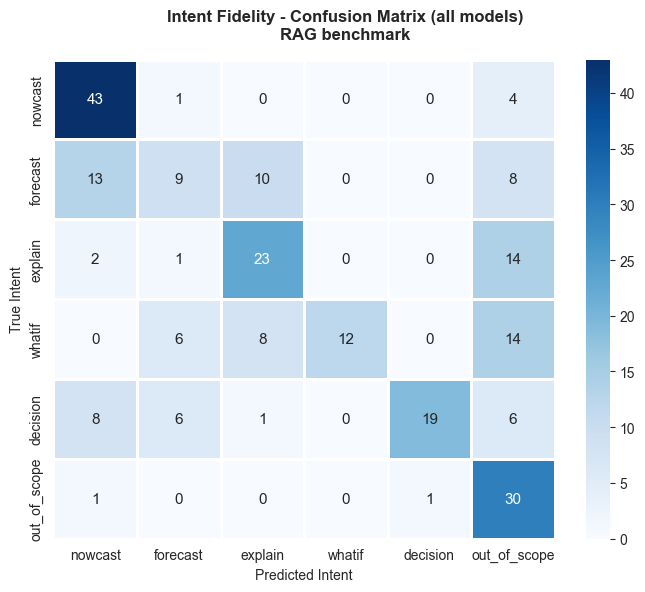


               precision    recall  f1-score   support

     nowcast       0.64      0.90      0.75        48
    forecast       0.39      0.23      0.29        40
     explain       0.55      0.57      0.56        40
      whatif       1.00      0.30      0.46        40
    decision       0.95      0.47      0.63        40
out_of_scope       0.39      0.94      0.56        32

    accuracy                           0.57       240
   macro avg       0.65      0.57      0.54       240
weighted avg       0.66      0.57      0.55       240



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

df_if = pd.read_csv(RESULTS_DIR / 'intent_fidelity.csv')

INTENT_LABELS = ['nowcast', 'forecast', 'explain', 'whatif', 'decision', 'out_of_scope']

# Overall accuracy
acc = (df_if['intent'] == df_if['predicted_intent']).mean()
print(f'Overall Intent Fidelity: {acc:.3f}')

print('\nPer model:')
print(df_if.groupby('model').apply(lambda g: (g['intent'] == g['predicted_intent']).mean()).to_string())

# Confusion matrix (aggregated across models)
cm = confusion_matrix(df_if['intent'], df_if['predicted_intent'], labels=INTENT_LABELS)

fig, ax = plt.subplots(figsize=(7, 6))
fig.suptitle('Intent Fidelity - Confusion Matrix (all models)\nRAG benchmark',
             fontsize=12, fontweight='bold')

sns.heatmap(pd.DataFrame(cm, index=INTENT_LABELS, columns=INTENT_LABELS),
            annot=True, fmt='d', cmap='Blues', ax=ax,
            linewidths=0.8, linecolor='white',
            annot_kws={'size': 11})
ax.set_xlabel('Predicted Intent')
ax.set_ylabel('True Intent')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'intent_fidelity.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print('\n', classification_report(df_if['intent'], df_if['predicted_intent'],
                                   labels=INTENT_LABELS, zero_division=0))

## 8. Summary Dashboard

Radar chart tous modèles × toutes métriques + tableau LaTeX pour la thèse.

In [ ]:
# Aggregate all metrics per model
# (assumes previous sections have been run)
df_no_refine = results_df[~results_df['refine'] & results_df['answer'].notna()].copy()

summary_rows = []
for model in MODELS:
    m = df_no_refine[df_no_refine['model'] == model]

    fa  = fa_by_model.get(model, np.nan)
    uocr = uocr_by_model.get(model, np.nan)
    lat = m['t_llm_s'].mean()
    lat_norm = 1 - min(lat / 60, 1)  # normalize: 0s→1, 60s→0
    rg  = rg_by_model.get(model, np.nan)
    ar  = ar_by_model.get(model, np.nan)

    # CLC: mean of all pairs for this model
    if 'clc_scores' in dir():
        clc = clc_scores[clc_scores['model']==model]['similarity'].mean()
    else:
        clc = np.nan

    # IF accuracy for this model
    if os.path.exists(RESULTS_DIR / 'intent_fidelity.csv'):
        df_if_m = pd.read_csv(RESULTS_DIR / 'intent_fidelity.csv')
        df_if_m = df_if_m[df_if_m['model']==model]
        intent_f = (df_if_m['intent'] == df_if_m['predicted_intent']).mean()
    else:
        intent_f = np.nan

    summary_rows.append({
        'Model': model.split(':')[0],
        'Factual Acc. (FA)': round(fa, 3),
        'UOCR': round(uocr, 3),
        'Latency Score': round(lat_norm, 3),
        'Answer Relevancy': round(ar, 3),
        'CLC (EN↔FR/TH)': round(clc, 3),
        'Intent Fidelity': round(intent_f, 3),
    })

summary = pd.DataFrame(summary_rows).set_index('Model')
print(summary.to_string())

             Factual Acc. (FA)   UOCR  Latency Score  Answer Relevancy  CLC (EN↔FR/TH)  Intent Fidelity
Model                                                                                                  
phi3                     0.833  0.375          0.952             0.716           0.735            0.567
llama3.1                 0.917  0.750          0.934             0.777           0.765            0.483
qwen2.5                  0.917  0.500          0.884             0.782           0.792            0.650
gpt-4o-mini              0.917  0.625          0.961             0.836           0.807            0.567


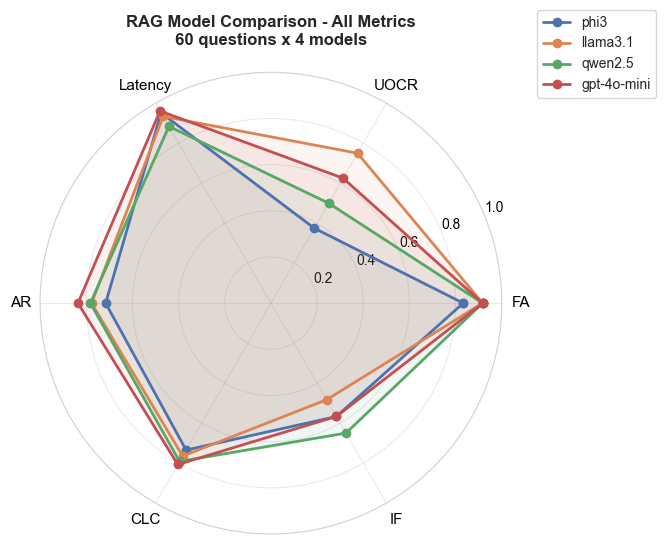

In [ ]:
metrics = summary.columns.tolist()
N = len(metrics)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

short_metrics = ['FA', 'UOCR', 'Latency', 'AR', 'CLC', 'IF']

for model_name, row in summary.iterrows():
    model_key = next((m for m in MODELS if MODEL_LABELS[m] == model_name), model_name)
    color = MODEL_COLORS.get(model_key, '#4C72B0')
    values = row.fillna(0).tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=model_name, color=color)
    ax.fill(angles, values, alpha=0.08, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(short_metrics, size=11)
ax.set_ylim(0, 1)
ax.set_title('RAG Model Comparison - All Metrics\n60 questions x 4 models',
             size=12, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=10)
ax.grid(True, alpha=0.4)
ax.tick_params(colors='black')
for spine in ax.spines.values():
    spine.set_edgecolor('lightgray')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'radar_summary.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

In [ ]:
# Export LaTeX table for thesis
latex = summary.to_latex(
    float_format='%.3f',
    caption='RAG Evaluation Results — Comparison across models and metrics',
    label='tab:rag_eval',
    bold_rows=True,
)
latex_path = RESULTS_DIR / 'summary_table.tex'
with open(latex_path, 'w') as f:
    f.write(latex)
print(f'LaTeX table saved to {latex_path}')
print(latex)

LaTeX table saved to /Users/mathieuzilli/Desktop/Thai/TFE_Phuket/notebooks/eval/results/summary_table.tex
\begin{table}
\caption{RAG Evaluation Results — Comparison across models and metrics}
\label{tab:rag_eval}
\begin{tabular}{lrrrrrr}
\toprule
 & Factual Acc. (FA) & UOCR & Latency Score & Answer Relevancy & CLC (EN↔FR/TH) & Intent Fidelity \\
Model &  &  &  &  &  &  \\
\midrule
\textbf{phi3} & 0.833 & 0.375 & 0.952 & 0.716 & 0.735 & 0.567 \\
\textbf{llama3.1} & 0.917 & 0.750 & 0.934 & 0.777 & 0.765 & 0.483 \\
\textbf{qwen2.5} & 0.917 & 0.500 & 0.884 & 0.782 & 0.792 & 0.650 \\
\textbf{gpt-4o-mini} & 0.917 & 0.625 & 0.961 & 0.836 & 0.807 & 0.567 \\
\bottomrule
\end{tabular}
\end{table}



In [ ]:
# Save full summary CSV
summary.to_csv(RESULTS_DIR / 'summary.csv')
print('Summary saved.')
print(f'All results in: {RESULTS_DIR}')
print('Files:')
for f in sorted(RESULTS_DIR.iterdir()):
    print(f'  {f.name}')

Summary saved.
All results in: /Users/mathieuzilli/Desktop/Thai/TFE_Phuket/notebooks/eval/results
Files:
  answer_relevancy.png
  clc_responses.csv
  crosslang_consistency.png
  fa_uocr.png
  intent_fidelity.csv
  intent_fidelity.png
  latency.png
  radar_summary.png
  raw_responses.csv
  refinement_gain.png
  summary.csv
  summary_table.tex
